In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/netflix-content-dataset/netflix_titles.csv


# **Step 1 - Import Libraries**

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


# **Step 2: Load Data**

In [3]:
# Load the Dataset

path = '/kaggle/input/datasets/muhammadumer7804/netflix-content-dataset/'

df = pd.read_csv(path + 'netflix_titles.csv')

print('Dataset loaded successfully!')
print('Shape:', df.shape)
print()


Dataset loaded successfully!
Shape: (8807, 12)



In [4]:
print('Column Names:')
print(df.columns.tolist())

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


# **Step 3: First Look**

In [5]:
# First Look at the Data

# see first 5 rows
print('First 5 rows:')
print(df.head())

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

In [6]:
# check data types
print('Data Types:')
print(df.dtypes)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


#  **Step 4: Check Missing Values**

In [7]:
# Check Missing Values

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

print('Missing Values:')
for col in df.columns:
    if missing[col] > 0:
        print(f'{col}: {missing[col]} missing ({missing_pct[col]}%)')

Missing Values:
director: 2634 missing (29.91%)
cast: 825 missing (9.37%)
country: 831 missing (9.44%)
date_added: 10 missing (0.11%)
rating: 4 missing (0.05%)
duration: 3 missing (0.03%)


# **Step 5: Handle Missing Values**

In [8]:
# Handle Missing Values

# director, cast, country — fill with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# date_added, rating, duration — very few missing
# drop these rows
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

print('Missing values handled!')
print('Rows remaining:', len(df))
print()
print('Missing values now:')
print(df.isnull().sum())

Missing values handled!
Rows remaining: 8790

Missing values now:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


# **Step 6: Check Duplicates**

In [9]:
#Check Duplicate Rows

print('Duplicate rows:', df.duplicated().sum())

df.drop_duplicates(inplace=True)

print('After removing duplicates:', len(df))

Duplicate rows: 0
After removing duplicates: 8790


# **Step 7: Fix Data Types**

In [10]:
# Fix Data Types

# convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# extract year and month from date_added
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print('Data types fixed!')
print()
print(df[['date_added', 'year_added', 'month_added']].head())

Data types fixed!

  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


# **Step 8: Data Cleaning Summary**

In [11]:
# Step 8 - Data Cleaning Summary

print('Data Cleaning Complete!')
print()
print('Final shape    :', df.shape)
print('Missing values :', df.isnull().sum().sum())
print('Duplicates     :', df.duplicated().sum())
print()
print('Content types:')
print(df['type'].value_counts())
print()
print('Date range:')
print('From:', df['year_added'].min())
print('To  :', df['year_added'].max())

Data Cleaning Complete!

Final shape    : (8790, 14)
Missing values : 0
Duplicates     : 0

Content types:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Date range:
From: 2008
To  : 2021


# **Chart 1: Movies vs TV Shows**

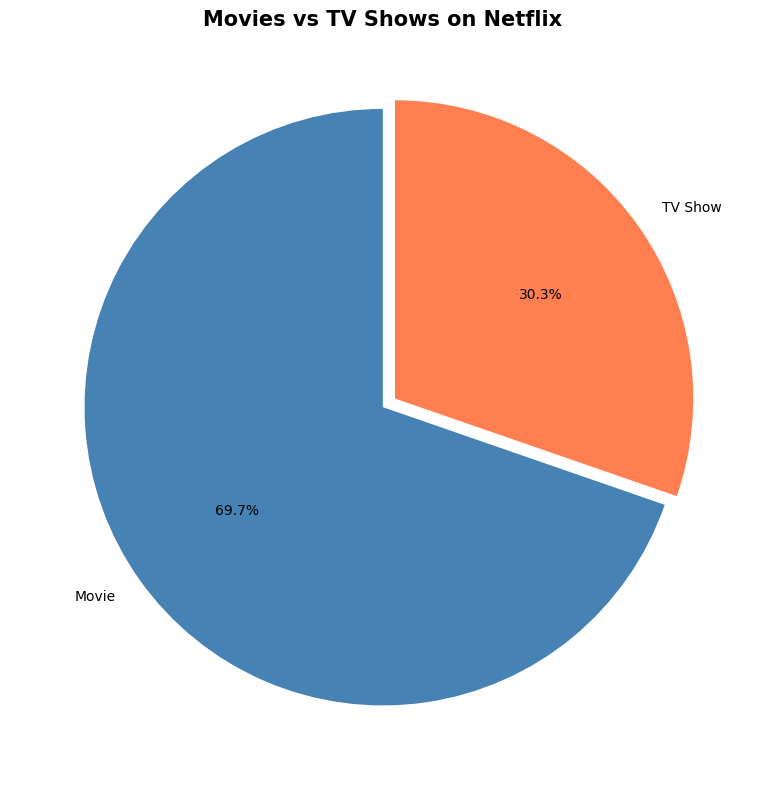

In [12]:
# Chart 1 - Movies vs TV Shows Distribution

content_counts = df['type'].value_counts().reset_index()
content_counts.columns = ['Type', 'Count']

plt.figure(figsize=(8, 8))

plt.pie(content_counts['Count'],
        labels=content_counts['Type'],
        autopct='%1.1f%%',
        colors=['steelblue', 'coral'],
        startangle=90,
        explode=[0, 0.05])

plt.title('Movies vs TV Shows on Netflix',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Movies vs TV Shows — Explanation

movies  = df[df['type'] == 'Movie'].shape[0]
tvshows = df[df['type'] == 'TV Show'].shape[0]
total   = len(df)

movies_pct  = round(movies  / total * 100, 1)
tvshows_pct = round(tvshows / total * 100, 1)

print('Movies vs TV Shows Analysis')
print()
print(f'Total content  : {total}')
print(f'Movies         : {movies} ({movies_pct}%)')
print(f'TV Shows       : {tvshows} ({tvshows_pct}%)')
print()
print('Insight:')
print(f'Netflix has {movies_pct}% Movies and {tvshows_pct}% TV Shows.')
print('Movies are clearly dominating the platform.')

Movies vs TV Shows Analysis

Total content  : 8790
Movies         : 6126 (69.7%)
TV Shows       : 2664 (30.3%)

Insight:
Netflix has 69.7% Movies and 30.3% TV Shows.
Movies are clearly dominating the platform.


# **Chart 2: Top 10 Countries**

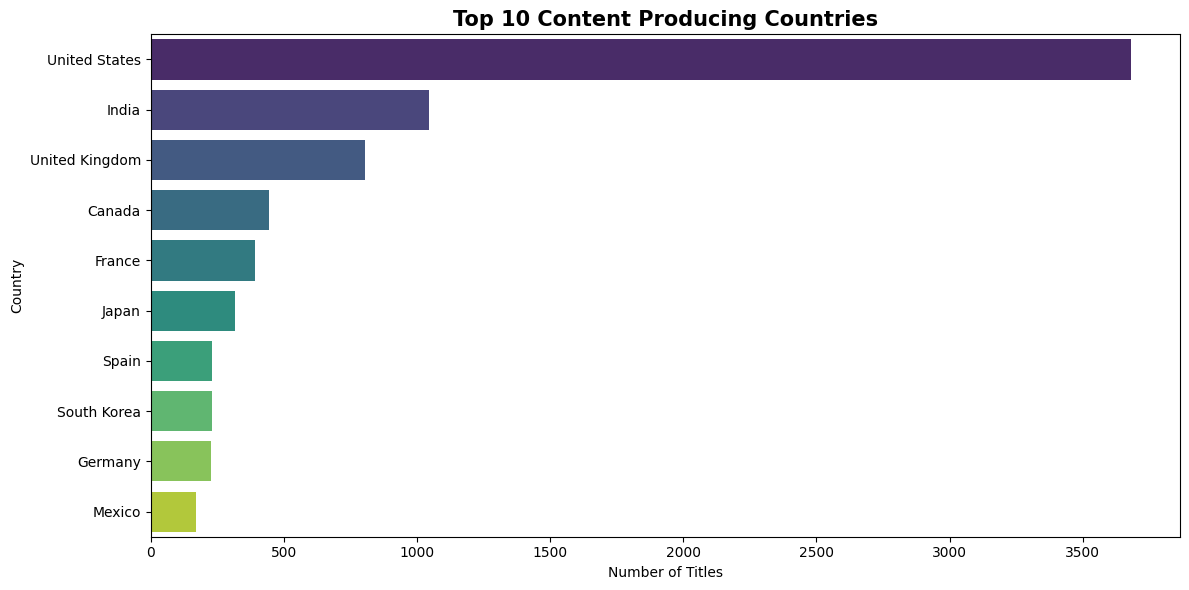

Top 3 countries:
1. United States — 3681 titles
2. India — 1046 titles
3. United Kingdom — 805 titles


In [14]:
# Top 10 Content Producing Countries

top_countries = df[df['country'] != 'Unknown']['country'].str.split(',').explode()
top_countries = top_countries.str.strip().value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Count']

plt.figure(figsize=(12, 6))

sns.barplot(data=top_countries, x='Count', y='Country', palette='viridis')

plt.title('Top 10 Content Producing Countries',
          fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# explanation
print('Top 3 countries:')
for i in range(3):
    print(f'{i+1}. {top_countries["Country"][i]} — {top_countries["Count"][i]} titles')

# **Chart 3: Content Added Per Year**

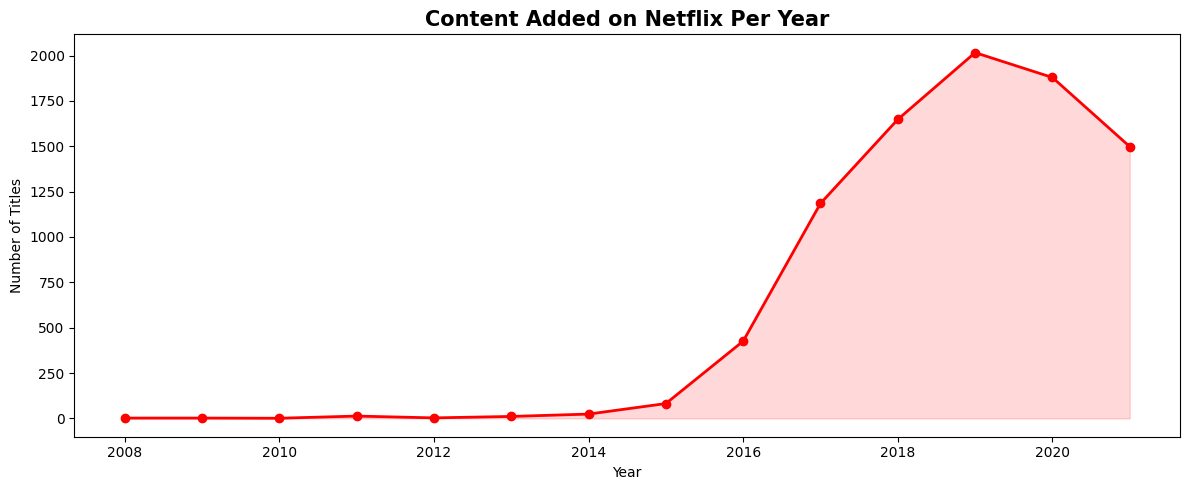

Peak year: 2019 with 2016 titles added


In [15]:
# Content Added Per Year
# how netflix grew over the years

yearly = df.groupby('year_added')['title'].count().reset_index()
yearly.columns = ['Year', 'Count']

plt.figure(figsize=(12, 5))

plt.plot(yearly['Year'], yearly['Count'],
         marker='o', linewidth=2, color='red')

plt.fill_between(yearly['Year'], yearly['Count'],
                 alpha=0.15, color='red')

plt.title('Content Added on Netflix Per Year',
          fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

# explanation
peak_year = yearly.loc[yearly['Count'].idxmax()]
print(f'Peak year: {int(peak_year["Year"])} with {peak_year["Count"]} titles added')